<a href="https://colab.research.google.com/github/vorhersager/deep-learning-jax/blob/main/Tutorial_9_Training_a_Self_Driving_Racer_with_Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Tutorial 9: Training a Self-Driving Racer with Reinforcement Learning

**Intructor**: John Sipple

**Important Note:** Due to the computational demands of simulating physics and training deep reinforcement learning models simultaneously, this tutorial works best with the High-RAM and advanced hardware accelerators available with a Colab Pro Plus subscription.

### Overview

This tutorial explores how to teach an AI agent to drive an autonomous vehicle using Reinforcement Learning (RL). Rather than hard-coding steering instructions, you will establish a mathematical framework where the agent discovers how to drive through trial, error, and environmental feedback. The core of this tutorial involves building the **Soft Actor-Critic (SAC)** algorithm—an off-policy, actor-critic deep RL algorithm based on the maximum entropy framework—entirely from scratch using the JAX, Optax, and Flax ecosystem.

You will train the agent within **MetaDrive**, a highly efficient, procedurally generated 3D driving simulator running in "headless" mode for cloud compatibility.

### Key Concepts Explored:

* **The Reinforcement Learning Framework (MDP):** Establishing the Markov Decision Process, defining the Agent (the racer), the Environment (the track), continuous Action Spaces (steering and throttle/brake), and a Reward Function that encourages speed while penalizing erratic steering or crashing.
* **Soft Actor-Critic (SAC) Mechanics:** Implementing the dual-objective nature of SAC, where the agent maximizes both cumulative reward and exploration (entropy). This includes building a Squashed Gaussian Actor policy and Twin-Critic networks to evaluate the value of states without falling into overestimation bias.
* **Experience Replay Buffer:** Building a native, highly efficient Numpy replay buffer from scratch. This section explains how storing and randomly sampling past experiences breaks the temporal correlation of driving data, preventing the neural network from suffering catastrophic unlearning (e.g., forgetting how to turn right because it has been turning left for too long).
* **Procedural Generalization:** Utilizing MetaDrive's procedural content generation to build infinite variations of tracks. This forces the agent to learn the actual mechanics of driving rather than simply memorizing the layout of a single, static track.
* **Architecture & Training Loop:** Designing the internal neural network architectures using Flax, compiling the complex gradient update steps with `jax.jit`, and executing a time-bounded main training loop complete with model checkpointing (via Orbax) and performance plotting.

Before diving into the code, it is essential to understand the mathematical framework that allows an AI to learn how to drive.
Reinforcement Learning (RL) isn't about telling the car how to steer; it's about telling the car what a good outcome looks like and letting it discover the steering maneuvers itself.

##The Reinforcement Learning Framework
At its core, RL is a computational approach to learning from action. An **Agent** (our racer) interacts with an **Environment** (the racetrack) and receives feedback in the form of numerical **Rewards**.

The goal of the agent is to learn a Policy ($\pi$)—a mapping from situations to actions—that maximizes the total cumulative reward over time.

##The Markov Decision Process (MDP)

We formalize this interaction using a **Markov Decision Process**. An MDP is defined by the tuple $(S, A, P, R, \gamma)$:

* $S$ (**State Space**): The set of all possible situations the agent can find itself in (e.g., its speed, position on the track, and distance to walls).

* $A$ (**Action Space**): The set of all possible moves the agent can make (e.g., steering angle and throttle pressure).

* $P$ (**Transition Probability**): The physics of the world. Given a state and an action, what is the probability of landing in a new state?

* $R$ (**Reward Function**): The immediate signal given to the agent after taking an action.

* $\gamma$ (**Discount Factor**): A value between 0 and 1 that determines how much the agent cares about future rewards versus immediate ones.

---

##Defining our Racing Components

###1. The Agent (Soft Actor-Critic)

In this tutorial, our agent uses the **Soft Actor-Critic (SAC)** algorithm. SAC is a "Maximum Entropy" framework. This means the agent doesn't just try to find the best path; it tries to find the best path while remaining as** random (exploratory) as possible**. This prevents the racer from getting "stuck" in local optima, such as learning to drive in circles because it's afraid of crashing.

###2. The Environment (MetaDrive)

We use **MetaDrive,** a simulator that provides the agent with a **Vector State** observation.

* **Observations**: Instead of raw pixels, our agent "sees" a 1D array. This includes the car's current velocity, steering angle, and a simulated LiDAR scan (lasers that measure the distance to the road boundaries and other obstacles).

###3. The Action Space (Continuous Control)
Our racer has two continuous control inputs:

1. Steering: A value from $-1.0$ (hard left) to $+1.0$ (hard right).

2. Acceleration/Brake: A value from $-1.0$ (full brake) to $+1.0$ (full throttle).

###4. The Reward Function
The "brain" of the racer is shaped by its reward. In MetaDrive, the default reward is designed to encourage efficient progress:V

* **Velocity Reward**: Positive points for moving forward along the center of the lane.

* **Steering Penalty**: Small negative points for erratic, shaky steering.

* **Termination Penalty**: A massive negative penalty (e.g., $-50$) if the car crashes into a barrier or drives off the road.

By maximizing these values, the agent naturally learns that the most "profitable" behavior is to drive as fast as possible while staying perfectly within the lane lines.

# Prerequisites & Installation
Run this cell first to install the required libraries for JAX, Flax (for neural networks), Optax (for optimization), and the **MetaDrive** autonomous driving simulator.

In [ ]:
# 1. Install core deep learning and optimization libraries
!pip install -q jax jaxlib flax optax

# 2. Fix the JAX XLA / GPU Compiler crash
!pip install --upgrade nvidia-cuda-nvcc-cu12

# 3. Fix the TFP / JAX compatibility crash
!pip install -q tfp-nightly[jax]

# 4. Install MetaDrive DIRECTLY from the GitHub main branch (Python 3.12 compatible!)
!pip install -q git+https://github.com/metadriverse/metadrive.git@main

# 5. Install utilities for checkpointing and plotting
!pip install -q orbax-checkpoint matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 88.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 97.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 139.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 139.7 MB/s eta 0:00:00


#Part 1. Soft Actor-Critic

To understand Soft Actor-Critic (SAC), we must look at it as a bridge between Maximum Entropy Reinforcement Learning and the Actor-Critic architecture. Unlike standard RL, where the agent only cares about the reward, SAC agents care about the reward and their freedom to explore.1.

##1. The Mathematical Objectives

The Entropy-Augmented Objective

Standard RL maximizes $\sum r_t$. SAC maximizes the Maximum Entropy Objective:

$$J(\pi) = \sum_{t=0}^{T} \mathbb{E}_{(s_t, a_t) \sim \rho_\pi} [r(s_t, a_t) + \alpha \mathscr{H}(\pi(\cdot|s_t))]$$

* $\mathscr{H}(\pi)$: The entropy, calculated as $-\log \pi(a|s)$. It measures how "spread out" the policy is.

* $\alpha$ (**Temperature**): Determines the trade-off. High $\alpha$ leads to more exploration; low $\alpha$ leads to near-deterministic behavior.


### The Twin-Critic (Soft Q-Function)
To avoid the overestimation bias common in Q-learning, SAC uses two Critic networks ($Q_{\theta_1}, Q_{\theta_2}$). They are trained to minimize the **Soft Bellman Residual**:

$$J_Q(\theta_i) = \mathbb{E}_{(s,a,r,s',d) \sim D} \left[ \frac{1}{2} (Q_{\theta_i}(s,a) - \hat{y})^2 \right]$$

Where the target value $\hat{y}$ is:

$$\hat{y} = r + \gamma(1-d) \left( \min_{j=1,2} Q_{\bar{\theta}_j}(s', a') - \alpha \log \pi_\phi(a'|s') \right)$$

Note: We use the **target** critic networks ($\bar{\theta}$) to compute $\hat{y}$ for stability.

###The Actor (Policy)
The Actor is trained to maximize the expected Q-value while maintaining high entropy. We use the **Reparameterization Trick** ($a = f_\phi(\epsilon; s)$) to allow gradients to flow from the Critic back into the Actor:

$$J_\pi(\phi) = \mathbb{E}_{s \sim D, \epsilon \sim \mathscr{N}} [\alpha \log \pi_\phi(f_\phi(\epsilon; s)|s) - Q_{\theta_1}(s, f_\phi(\epsilon; s))]$$

##2. The SAC Algorithm Logic

The power of SAC lies in the tight feedback loop between the networks. Here is the step-by-step interaction:

###Step 1: Data Collection
The Actor interacts with the environment. Because it is a "Soft" policy, it outputs a distribution. We sample an action $a \sim \pi_\phi(s)$, execute it, and store the transition in the **Replay Buffer**.

###Step 2: The Critic's "Reality Check"
We sample a batch from the buffer. The **Critics** ($Q_{\theta_1}, Q_{\theta_2}$) look at what happened and compare their previous guesses to the actual reward plus the discounted future value. They update their weights to become more accurate "judges" of state-action pairs.

###Step 3: The Actor's Improvement
The **Actor** asks the Critics: "Which actions do you think are valuable?"

* The Actor updates its weights to move the "mean" of its distribution toward actions that the Critics rated highly.

* Simultaneously, the entropy term pushes the "standard deviation" to stay wide enough so the agent doesn't stop exploring.

###Step 4: Temperature Adjustment

The agent automatically updates $\alpha$. If the entropy drops below a target threshold (meaning the agent is getting "stuck" or too certain), $\alpha$ increases to force more randomness.

###Step 5: Moving Averages

We don't update the Target Critics ($\bar{\theta}$) directly with gradients. Instead, they "track" the main Critics slowly using Polyak Averaging:

$$\bar{\theta} \leftarrow \tau \theta + (1 - \tau) \bar{\theta}$$

This ensures the target used for the Bellman equation doesn't shift too violently, preventing the learning process from oscillating or diverging.

Below is the complete pseudocode for SAC with automatic temperature tuning, expressed in mathematical notation:

##Algorithm: Soft Actor-Critic (SAC)

**Initialize:**
> Initial parameters $\phi$ (Actor), $\theta_1, \theta_2$ (Twin Critics)
>
>Target parameters $\bar{\theta}_1 \leftarrow \theta_1, \bar{\theta}_2 \leftarrow \theta_2$
>
>Replay buffer $\mathscr{D} \leftarrow \emptyset$
>
>Learning rates $\lambda_\phi, \lambda_\theta, \lambda_\alpha$ and target entropy $\bar{\mathscr{H}} = -\text{dim}(\mathscr{A})$

**For each iteration do:**

> 1. Environment Interaction:
>>
>>For each step in episode:
>>>Sample action from policy: $a_t \sim \pi_\phi(a_t|s_t)$
>>>
>>>Execute $a_t$, observe reward $r_t$, next state $s_{t+1}$, and terminal flag $d_t$
>>>
>>>Store transition: $\mathscr{D} \leftarrow \mathscr{D} \cup \{(s_t, a_t, r_t, s_{t+1}, d_t)\}$
> 2. Gradient Updates:
>>Sample mini-batch $B = \{(s, a, r, s', d)\}$ from $\mathscr{D}$:
>>>
>>>**Update Critics**:
>>>
>>>Compute the target $Q$-value:
>>>
>>>$$y = r + \gamma(1 - d) \left( \min_{j=1,2} Q_{\bar{\theta}_j}(s', \tilde{a}') - \alpha \log \pi_\phi(\tilde{a}'|s') \right), \quad \tilde{a}' \sim \pi_\phi(\cdot|s')$$
>>>
>>>Update $\theta_j$ by one step of gradient descent on the Bellman error:
>>>
>>>$$\nabla_{\theta_j} \frac{1}{|B|} \sum_{(s,a) \in B} (Q_{\theta_j}(s, a) - y)^2 \quad \text{for } j \in \{1, 2\}$$
>>>
>>>**Update Actor**:
>>>
>>>Update $\phi$ using the reparameterization trick $a_\phi(s, \epsilon) = \text{tanh}(\mu_\phi(s) + \sigma_\phi(s) \odot \epsilon)$:
>>>
>>>$$\nabla_\phi \frac{1}{|B|} \sum_{s \in B} \left( \alpha \log \pi_\phi(a_\phi(s, \epsilon)|s) - \min_{j=1,2} Q_{\theta_j}(s, a_\phi(s, \epsilon)) \right)$$
>>>
>>>**Update Temperature ($\alpha$)**:
>>>Update $\alpha$ by minimizing the dual objective:
>>>
>>>$$\nabla_\alpha \frac{1}{|B|} \sum_{s \in B} \left( -\alpha \log \pi_\phi(a|s) - \alpha \bar{\mathscr{H}} \right)$$

>3. **Target Network Synchronization**:
>Update target weights using Polyak averaging:
>
>$$\bar{\theta}_j \leftarrow \tau \theta_j + (1 - \tau) \bar{\theta}_j \quad \text{for } j \in \{1, 2\}$$

---

##Key Mathematical Components

* **Soft State Value**: The value of a state in SAC includes the expected future entropy: $V(s) = \mathbb{E}_{a \sim \pi} [Q(s, a) - \alpha \log \pi(a|s)]$.
* **The Reparameterization Trick**: To compute the gradient of the expectation $\mathbb{E}_{a \sim \pi_\phi} [Q(s, a)]$, we express the action as a deterministic function of the state and a noise vector $\epsilon \sim \mathscr{N}(0, I)$. This allows us to use backpropagation through the stochastic action choice.

* **Twin-Q Trick**: By taking the minimum of two independent $Q$ networks, we prevent the "overestimation bias" that often causes RL agents to become overconfident in poor actions.

# Part 2: Environment and Replay Buffer Setup

We will instantiate the **MetaDrive** environment in "headless" mode (perfect for cloud training) and build a highly efficient, native Numpy experience replay buffer from scratch.



## Overview of the Simulator: MetaDrive
To train our autonomous racer, we need an environment that provides realistic vehicle dynamics and complex road networks, but is lightweight enough to run efficiently in a cloud environment like Google Colab. For this, we are using **MetaDrive**.

MetaDrive is an open-source, highly compositional 3D driving simulator explicitly designed for Reinforcement Learning (RL) research. It bridges the gap between overly simple 2D toy environments and computationally massive simulators like CARLA or Unreal Engine.

Here is why MetaDrive is the gold standard for this tutorial:

### 1. Procedural Generation (Infinite Generalization)
One of the biggest challenges in RL is **overfitting**—where an agent memorizes a single track instead of learning how to actually drive. MetaDrive solves this using Procedural Content Generation (PCG). It pieces together basic building blocks (straight roads, curves, intersections, roundabouts, and toll stations) to generate a theoretically infinite number of unique maps. This forces our Soft Actor-Critic agent to learn generalized driving behaviors.

### 2. Flexible Observation Spaces (Sensors)
MetaDrive allows researchers to tap into several different "sensors" depending on the complexity of the neural network they want to build:
* **Vector State (What we are using):** A low-dimensional 1D array containing the ego-vehicle's kinematics (speed, steering angle), distance to road edges, and simulated 2D LiDAR point clouds detecting other vehicles. This is perfect for standard multi-layer perceptron (MLP) networks.
* **RGB Cameras & Top-Down Semantics:** High-dimensional pixel arrays that require deep Convolutional Neural Networks (CNNs) to process.

### 3. Continuous Action Space
Unlike discrete games (e.g., pressing the 'Left' or 'Right' arrow keys), real driving requires smooth, continuous control. MetaDrive expects a continuous action vector `[Steering, Acceleration/Brake]`, where values range from `[-1.0, 1.0]`. This necessitates advanced continuous-control RL algorithms like Soft Actor-Critic (SAC) or Proximal Policy Optimization (PPO).

### 4. Extreme Computational Efficiency
Because RL requires agents to experience millions of steps of trial-and-error, simulation speed is a bottleneck. MetaDrive is highly optimized in C++ and Python, capable of running at over **1000 frames per second (FPS)** on standard hardware. It also runs flawlessly in "headless" mode (without rendering a graphical window), allowing us to train a capable self-driving agent in a Google Colab notebook in just a few minutes.

### 5. Multi-Agent & Traffic Simulation
While we are starting with a single agent on an empty track, MetaDrive natively supports dense, rule-based background traffic and multi-agent interactions. This allows researchers to easily scale their experiments from simple lane-keeping to complex, dense-traffic highway merging.



##The Replay Buffer - Breaking Correlations and Stabilizing Learning

In standard Supervised Learning, we assume that our data points are **Independent and Identically Distributed (I.I.D.)**. However, in Reinforcement Learning, this assumption is violently broken.


When a car drives down a track, the state at time $t+1$ is almost identical to the state at time $t$. If we trained our neural network on these samples as they happened (online learning), the network would see a sequence of highly correlated data. This leads to two major issues:

1. **Temporal Correlations**: The network becomes overfit to the specific "maneuver" it is currently performing. If the car is in a long left turn, the gradients will constantly push the weights toward "turning left," causing it to "forget" how to drive straight or turn right.

2. **Catastrophic Unlearning**: Because the agent’s own actions determine the data it sees, it can fall into a feedback loop. A small error in the policy leads to poor data, which makes the policy even worse, until the network's weights collapse entirely—a phenomenon known as catastrophic forgetting or unlearning.

**The Solution: Experience Replay**

To solve this, we use an **Experience Replay Buffer**. Instead of learning from a sample and throwing it away, we store the transition $(s, a, r, s', d)$ in a large memory bank.

During the training step, we **uniformly sample a random mini-batch** of experiences from this buffer.

**Why this works:**

* **Breaking Correlations**: By sampling randomly, the mini-batch contains transitions from different parts of the track, different speeds, and even different previous versions of the policy. This "shuffles" the data, making it look I.I.D. to the neural network.

* **Data Efficiency**: Each transition can be used for multiple gradient updates, allowing the agent to "ruminate" on past experiences to extract maximum information.

In the following code, we implement this as a **Circular Buffer**—once the memory is full, the oldest memories are overwritten by the newest ones, ensuring the agent stays focused on "recent" physics while maintaining enough diversity to stay stable.

In [ ]:
import gym
from metadrive import MetaDriveEnv
import numpy as np

# 1. Instantiate the MetaDrive Environment
# We disable rendering during training to maximize speed in Colab.
env_config = {
    "use_render": False,
    "out_of_road_penalty": 50.0, # Encourage staying on the track
    "crash_vehicle_penalty": 50.0
}
env = MetaDriveEnv(env_config)

# Handle modern Gym API resets
obs = env.reset()
if isinstance(obs, tuple):
    obs = obs[0]

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

print(f"MetaDrive Initialized! Observation Dim: {obs_dim}, Action Dim: {action_dim}")

# 2. Setup Native Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        # Pre-allocate memory for extreme efficiency
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.action = np.zeros((capacity, action_dim), dtype=np.float32)
        self.reward = np.zeros((capacity,), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.done = np.zeros((capacity,), dtype=np.float32)

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr] = obs
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.done[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # Randomly sample indices
        ind = np.random.randint(0, self.size, size=batch_size)
        return {
            'obs': self.obs[ind],
            'action': self.action[ind],
            'reward': self.reward[ind],
            'next_obs': self.next_obs[ind],
            'done': self.done[ind]
        }

# Instantiate the buffer
buffer = ReplayBuffer(capacity=100000, obs_dim=obs_dim, action_dim=action_dim)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
[INFO] Environment: MetaDriveEnv
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecation

MetaDrive Initialized! Observation Dim: 259, Action Dim: 2


#Part 3: Defining the SAC Architecture (Actor & Critic)

We use Flax and Optax to build the neural networks from scratch. The Actor uses a Squashed Gaussian policy (applying tanh to constrain steering/acceleration limits), while the Critic computes Twin Q-values.

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions

# --- Actor Network (Squashed Gaussian Policy) ---
class Actor(nn.Module):
    action_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.relu(nn.Dense(256)(x))
        x = nn.relu(nn.Dense(256)(x))
        mean = nn.Dense(self.action_dim)(x)
        log_std = nn.Dense(self.action_dim)(x)

        log_std = jnp.clip(log_std, -20, 2)
        std = jnp.exp(log_std)

        # RETURN ARRAYS, NOT TFP DISTRIBUTIONS!
        return mean, std

def sample_action(mean, std, key):

    dist = tfd.MultivariateNormalDiag(loc=mean, scale_diag=std)

    raw_action = dist.sample(seed=key)
    log_prob = dist.log_prob(raw_action)
    action = jnp.tanh(raw_action)

    log_prob -= jnp.sum(jnp.log(1 - action ** 2 + 1e-6), axis=-1)
    return action, log_prob

# --- Critic Network (Twin Q-Networks) ---
class TwinCritic(nn.Module):
    @nn.compact
    def __call__(self, obs, action):
        x = jnp.concatenate([obs, action], axis=-1)

        q1 = nn.relu(nn.Dense(256)(x))
        q1 = nn.relu(nn.Dense(256)(q1))
        q1 = nn.Dense(1)(q1)

        q2 = nn.relu(nn.Dense(256)(x))
        q2 = nn.relu(nn.Dense(256)(q2))
        q2 = nn.Dense(1)(q2)

        return jnp.squeeze(q1, -1), jnp.squeeze(q2, -1)

# --- Architecture Rendering Method ---
def render_architecture(model, dummy_inputs):
    print(f"--- Rendering Architecture: {model.__class__.__name__} ---")
    tabulated = nn.tabulate(model, jax.random.PRNGKey(0), compute_flops=True)
    print(tabulated(*dummy_inputs))
    print("-" * 60)

# Instantiate models and render!
actor_model = Actor(action_dim=action_dim)
critic_model = TwinCritic()

dummy_obs = jnp.ones((1, obs_dim))
dummy_act = jnp.ones((1, action_dim))

# This will now print beautiful architecture tables without crashing!
render_architecture(actor_model, (dummy_obs,))
render_architecture(critic_model, (dummy_obs, dummy_act))

--- Rendering Architecture: Actor ---

                                 Actor Summary                                  
┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module ┃ inputs         ┃ outputs        ┃ flops ┃ params          ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│         │ Actor  │ float32[1,259] │ - float32[1,2] │ 0     │                 │
│         │        │                │ - float32[1,2] │       │                 │
├─────────┼────────┼────────────────┼────────────────┼───────┼─────────────────┤
│ Dense_0 │ Dense  │ float32[1,259] │ float32[1,256] │ 0     │ bias:           │
│         │        │                │                │       │ float32[256]    │
│         │        │                │                │       │ kernel:         │
│         │        │                │                │       │ float32[259,25… │
│         │        │                │                │       │        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Part 4: SAC Update Step & Gradient Computations

Here we define the JIT-compiled optimization step that updates the Actor, the Critic, and the temperature parameter $\alpha$ based on Reverb batches

In [ ]:
@jax.jit
def update_step(rng, actor_params, critic_params, target_critic_params, log_alpha,
                actor_opt_state, critic_opt_state, alpha_opt_state, batch):

    obs, action, reward, next_obs, done = batch['obs'], batch['action'], batch['reward'], batch['next_obs'], batch['done']
    alpha = jnp.exp(log_alpha)
    gamma = 0.99
    tau = 0.005

    # --- 1. Critic Update ---
    def critic_loss_fn(c_params):

        next_mean, next_std = actor_model.apply(actor_params, next_obs)
        next_action, next_log_prob = sample_action(next_mean, next_std, rng)

        target_q1, target_q2 = critic_model.apply(target_critic_params, next_obs, next_action)
        target_q = jnp.minimum(target_q1, target_q2) - alpha * next_log_prob
        target_q = reward + gamma * (1.0 - done) * target_q

        q1, q2 = critic_model.apply(c_params, obs, action)
        critic_loss = jnp.mean((q1 - target_q)**2) + jnp.mean((q2 - target_q)**2)
        return critic_loss

    c_loss, c_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
    c_updates, critic_opt_state = critic_tx.update(c_grads, critic_opt_state)
    critic_params = optax.apply_updates(critic_params, c_updates)

    # --- 2. Actor Update ---
    def actor_loss_fn(a_params):

        curr_mean, curr_std = actor_model.apply(a_params, obs)
        curr_action, curr_log_prob = sample_action(curr_mean, curr_std, rng)

        q1, q2 = critic_model.apply(critic_params, obs, curr_action)
        q = jnp.minimum(q1, q2)
        actor_loss = jnp.mean(alpha * curr_log_prob - q)
        return actor_loss, curr_log_prob

    (a_loss, log_probs), a_grads = jax.value_and_grad(actor_loss_fn, has_aux=True)(actor_params)
    a_updates, actor_opt_state = actor_tx.update(a_grads, actor_opt_state)
    actor_params = optax.apply_updates(actor_params, a_updates)

    # --- 3. Alpha Update ---
    target_entropy = -action_dim
    def alpha_loss_fn(l_alpha):
        return -jnp.mean(l_alpha * jax.lax.stop_gradient(log_probs + target_entropy))

    alpha_loss, alpha_grads = jax.value_and_grad(alpha_loss_fn)(log_alpha)
    alpha_updates, alpha_opt_state = alpha_tx.update(alpha_grads, alpha_opt_state)
    log_alpha = optax.apply_updates(log_alpha, alpha_updates)

    # --- 4. Soft Update ---
    target_critic_params = jax.tree_util.tree_map(
        lambda t, c: tau * c + (1 - tau) * t, target_critic_params, critic_params
    )

    return actor_params, critic_params, target_critic_params, log_alpha, actor_opt_state, critic_opt_state, alpha_opt_state, c_loss, a_loss

#Part 5: The Main Training Loop (15 Minutes, Gradient Updates & Checkpointing)


We will run a time-bounded loop. The prompt specifies to populate the buffer using a random policy while executing gradient updates once enough data exists, and plotting returns every 10 episodes. We also handle checkpointing using Orbax.

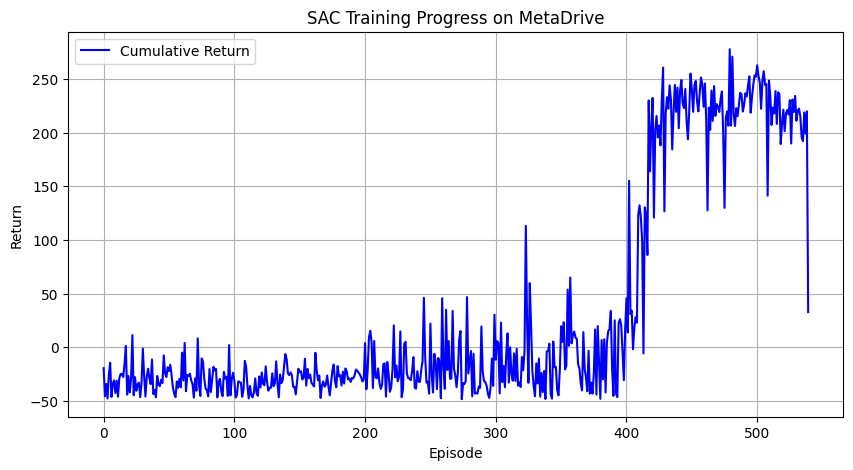

60.0-minute training period completed!


In [ ]:
import time
import matplotlib.pyplot as plt
import orbax.checkpoint
from IPython.display import clear_output

# Initialize parameters and optimizers
rng = jax.random.PRNGKey(42)
rng, actor_key, critic_key = jax.random.split(rng, 3)

actor_params = actor_model.init(actor_key, dummy_obs)
critic_params = critic_model.init(critic_key, dummy_obs, dummy_act)
target_critic_params = critic_params
log_alpha = jnp.array(0.0)

actor_tx = optax.adam(1e-5)
critic_tx = optax.adam(1e-5)
alpha_tx = optax.adam(1e-5)

actor_opt_state = actor_tx.init(actor_params)
critic_opt_state = critic_tx.init(critic_params)
alpha_opt_state = alpha_tx.init(log_alpha)

# Setup Orbax Checkpointer
ckpt_dir = '/tmp/sac_metadrive_checkpoints1'
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

# Metrics tracking
episode_returns = []
start_time = time.time()
MAX_TRAIN_TIME = 3600

episode = 0
global_step = 0
random_exploration_steps = 1000  # Enforce random policy initially to fill buffer

print(f"Starting SAC Training for {MAX_TRAIN_TIME/60} minutes...")

while time.time() - start_time < MAX_TRAIN_TIME:
    # 1. Safe Reset (Handles both old and new Gym APIs)
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]

    done = False
    ep_return = 0

    while not done:
        rng, action_key = jax.random.split(rng)

        # 2. Execute random policy for population, then switch to SAC Actor
        if global_step < random_exploration_steps:
            action = env.action_space.sample()
        else:
            # FIX: Expect mean and std arrays, build the distribution in sample_action
            mean, std = actor_model.apply(actor_params, jnp.expand_dims(obs, 0))
            action, _ = sample_action(mean, std, action_key)
            action = np.array(action)[0]

        # Map the [-1, 1] throttle output to a strictly positive [0.1, 1.0] range
        # Formula: new_val = ((old_val - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
        mapped_throttle = ((action[1] - (-1.0)) / 2.0) * (1.0 - 0.1) + 0.1

        # Overwrite the action before sending it to the environment
        executed_action = np.array([action[0], mapped_throttle])

        # 3. Safe Step (Handles Gym API v0.25 vs v0.26+)
        step_result = env.step(executed_action)
        if len(step_result) == 5:
            next_obs, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_obs, reward, done, _ = step_result

        # 4. Insert into our Custom Numpy Replay Buffer
        buffer.add(obs, action, reward, next_obs, float(done))

        obs = next_obs
        ep_return += reward
        global_step += 1

        # 5. Perform gradient updates
        if buffer.size >= 256:
            rng, update_key = jax.random.split(rng)
            batch_data = buffer.sample(256)

            (actor_params, critic_params, target_critic_params, log_alpha,
             actor_opt_state, critic_opt_state, alpha_opt_state, c_loss, a_loss) = update_step(
                update_key, actor_params, critic_params, target_critic_params, log_alpha,
                actor_opt_state, critic_opt_state, alpha_opt_state, batch_data
            )

        # Time limit break
        if time.time() - start_time >= MAX_TRAIN_TIME:
            print("Time limit reached during episode.")
            break

    episode += 1
    episode_returns.append(ep_return)

    # 6. Save, Load, and Plot every 10 episodes
    if episode % 10 == 0:
        # Checkpointing
        save_args = orbax.checkpoint.args.PyTreeSave(
            {'actor': actor_params, 'critic': critic_params}
        )
        checkpointer.save(f'{ckpt_dir}/ep_{episode}', save_args, force = True)

        # Verify Loading
        restore_args = orbax.checkpoint.args.PyTreeRestore(
            {'actor': actor_params, 'critic': critic_params}
        )
        loaded = checkpointer.restore(f'{ckpt_dir}/ep_{episode}', restore_args)

        # Plotting
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(episode_returns, label="Cumulative Return", color="blue")
        plt.xlabel("Episode")
        plt.ylabel("Return")
        plt.title("SAC Training Progress on MetaDrive")
        plt.legend()
        plt.grid()
        plt.show()

print(f"{MAX_TRAIN_TIME/60.0}-minute training period completed!")

#Part 6: Rendering the Final Episode

Now that the training window has closed, we execute the Actor in evaluation mode (using the deterministic mean of the action distribution instead of sampling).

In [ ]:
# Evaluate a final episode using the trained Actor


obs = env.reset()
if isinstance(obs, tuple):
    obs = obs[0]

done = False
final_return = 0
steps = 0


print("Evaluating final episode (headless)...")
while not done:
    # 1. FIX: Unpack the tuple (mean, std) returned by the updated Actor
    mean, std = actor_model.apply(actor_params, jnp.expand_dims(obs, 0))

    # 2. Extract the mean directly (no need for .loc anymore!)
    action = np.array(mean)[0]
    action = np.tanh(action)   # Apply squashing
    # Map the [-1, 1] throttle output to a strictly positive [0.1, 1.0] range
    mapped_throttle = ((action[1] - (-1.0)) / 2.0) * (1.0 - 0.1) + 0.1
    executed_action = np.array([action[0], mapped_throttle])

    # 3. Safe Step (Handles Gym API v0.25 vs v0.26+)
    step_result = env.step(executed_action)
    if len(step_result) == 5:
        obs, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
    else:
        obs, reward, done, _ = step_result

    final_return += reward
    steps += 1

print(f"Final Episode Return: {final_return:.2f} over {steps} steps.")
env.close()

# Note on Rendering: To visualize MetaDrive in Colab via video, you would typically
# configure the environment with `use_render=True` and capture the frames using
# `env.render(mode="rgb_array")`, appending them to a video writer like imageio.

Evaluating final episode (headless)...
Final Episode Return: 242.09 over 240 steps.


In [ ]:
!pip install -q imageio[ffmpeg] pillow

import imageio
import base64
import numpy as np
from PIL import Image
from IPython.display import HTML, display
from metadrive import MetaDriveEnv
from metadrive.engine.engine_utils import close_engine  # <-- THE ZOMBIE KILLER

print("Cleaning up background memory...")
# 1. Force-close any existing MetaDrive engines from previous cell runs!
close_engine()

print("Setting up Top-Down render environment...")

eval_config = {
    "use_render": False,
    "out_of_road_penalty": 50.0,
    "crash_vehicle_penalty": 50.0
}
eval_env = MetaDriveEnv(eval_config)

obs = eval_env.reset()
if isinstance(obs, tuple):
    obs = obs[0]

frames = []
done = False
steps = 0
max_steps = 1000
ep_return = 0.0

print("Simulating episode and capturing frames...")

while not done and steps < max_steps:
    mean, std = actor_model.apply(actor_params, jnp.expand_dims(obs, 0))
    action = np.array(mean)[0]
    action = np.tanh(action)
    # Map the [-1, 1] throttle output to a strictly positive [0.1, 1.0] range
    mapped_throttle = ((action[1] - (-1.0)) / 2.0) * (1.0 - 0.1) + 0.1
    executed_action = np.array([action[0], mapped_throttle])
    step_result = eval_env.step(executed_action)
    if len(step_result) == 5:
        obs, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        obs, reward, done, info = step_result

    ep_return += reward

    # Use native window=False to bypass display drivers natively
    frame = eval_env.render(mode="top_down", window=False)

    if frame is not None:
        if frame.shape[0] == 3:
            frame = np.transpose(frame, (1, 2, 0))

        frame = frame.astype(np.uint8)
        img = Image.fromarray(frame)
        img = img.resize((800, 800), Image.Resampling.NEAREST)
        frames.append(np.array(img))

    steps += 1

eval_env.close()

# --- DIAGNOSTICS ---
print("="*40)
print(f"Episode finished! Survived for {steps} steps.")
print(f"Total Reward: {ep_return:.2f}")

if ep_return < 10.0 and steps == 1000:
    print("🚨 DIAGNOSIS: THE LAZY AGENT 🚨")
    print("Your car is sitting perfectly still! It learned that driving causes crashes.")
    print("FIX: Train for longer (e.g., 15 minutes) so it has time to learn how to steer.")
print("="*40)

if len(frames) > 0 and ep_return >= 10.0:
    print("Encoding video of moving vehicle...")
    video_path = '/tmp/sac_racer_playback.mp4'

    imageio.mimsave(video_path, frames, fps=40, macro_block_size=None)

    video_file = open(video_path, "rb").read()
    video_url = f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"

    print("Done! Playing video:")
    display(HTML(f'''
    <div style="display: flex; justify-content: center;">
        <video width="600" controls autoplay loop style="border: 2px solid #333; border-radius: 8px;">
          <source src="{video_url}" type="video/mp4">
        </video>
    </div>
    '''))
elif len(frames) > 0:
    print("Skipping video rendering because the car didn't actually move.")

[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 1000
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: glxGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 1


Cleaning up background memory...
Setting up Top-Down render environment...
Simulating episode and capturing frames...


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

Episode finished! Survived for 243 steps.
Total Reward: 246.96
Encoding video of moving vehicle...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Done! Playing video:


#Part 7: Advanced Memory - Beyond Uniform Replay

In Part 2, we built a standard **Uniform Replay Buffer**. It acts as a simple First-In-First-Out (FIFO) queue. When it's time to train our Soft Actor-Critic network, we reach into the buffer and pull out a random handful of experiences, treating every memory as equally valuable.

While this works well for simple environments, it is highly inefficient for complex tasks. Imagine learning to drive: you don't learn much from driving straight on an empty highway for 10 minutes, but you learn a lot from that one time you almost spun out on a sharp corner.

In Reinforcement Learning, we want our agents to focus on the memories they can learn the most from.

##1. Prioritized Experience Replay (PER)
PER modifies the replay buffer to sample experiences based on their "surprise" or learning potential, rather than sampling uniformly.

**How it works:**

We measure "surprise" using the **Temporal Difference (TD) Error**—the difference between the Critic network's predicted Q-value and the actual target Q-value we calculated during the update step.

* High TD Error = The agent was completely wrong about this state. Replay this often.

* Low TD Error = The agent already understands this state perfectly. Ignore it.

Instead of uniform sampling, the probability $P(i)$ of sampling transition $i$ is:

$$P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}$$

Where $p_i$ is the absolute TD error ($|\delta_i| + \epsilon$) to ensure no transition has zero probability, and $\alpha$ is a hyperparameter that dictates how much prioritization is used ($\alpha = 0$ is uniform sampling, $\alpha = 1$ is full prioritization).

**The Catch: Bias Correction**

Because we are aggressively over-sampling high-error states, we change the underlying distribution of the data, which introduces bias into the neural network updates. To fix this, PER uses Importance-Sampling (IS) weights ($w_i$) to scale down the gradient updates of heavily sampled experiences:

$$w_i = \left( \frac{1}{N} \cdot \frac{1}{P(i)} \right)^\beta$$

Where $\beta$ controls how much we correct the bias (starting at a lower value and annealing to $1.0$ by the end of training).

##2. Hindsight Experience Replay (HER)

HER is a specialized buffer used almost exclusively for **Sparse Reward, Goal-Conditioned** tasks. Imagine asking a robot arm to push a puck to a specific target. It gets 0 reward if it misses, and +1 if it hits.

Until it accidentally hits the target, it gets zero feedback and learns nothing.How it works:HER uses a psychological trick: learning from failure by pretending it was the goal all along.

If the robot misses the target and pushes the puck to location B instead of location A, HER takes that failed trajectory, modifies the "Goal" in the memory to be location B, and recalculates the reward as a success (+1). It artificially creates positive feedback out of failed exploration.